## Classification Assignment

#### Assignment No. 12

#### Data File: framingham.csv

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler, LabelEncoder

try:
    from imblearn.over_sampling import SMOTE
    smote_available = True
except ImportError:
    smote_available = False
    print('Note: imbalanced-learn not installed. Run: pip install imbalanced-learn')

from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.naive_bayes      import GaussianNB

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.titleweight':'bold'})


In [3]:
df = pd.read_csv(r"G:\Jupyter Notebook\Practice Data Files\framingham.csv")

In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [6]:
df.shape

(4238, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [11]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [13]:
cfg = {
    "target_col": "TenYearCHD",
    "about_target": "TenYearCHD indicates the 10-year risk of coronary heart disease."
}


Target Variable: TenYearCHD
TenYearCHD indicates the 10-year risk of coronary heart disease.

Class Distribution:
  Class {cls}: {cnt:>5} samples  ({target_pct[cls]:.1f}%)
  Class {cls}: {cnt:>5} samples  ({target_pct[cls]:.1f}%)

Imbalance Ratio: {imbalance_ratio:.2f}:1
Dataset is IMBALANCED — SMOTE will be applied to balance it.


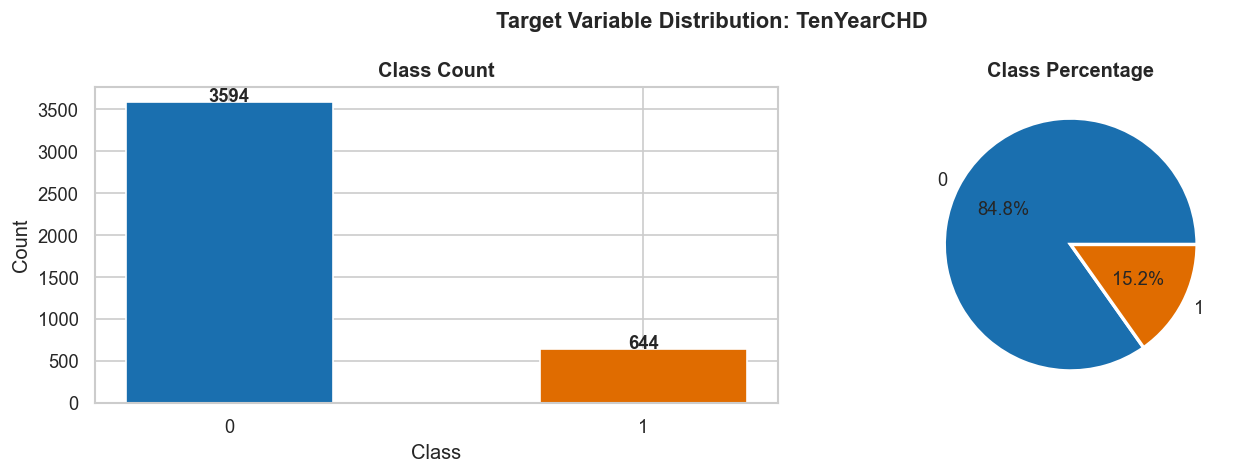

In [14]:
target_counts = df['TenYearCHD'].value_counts()
target_pct    = df['TenYearCHD'].value_counts(normalize=True) * 100

print(f'Target Variable: {cfg["target_col"]}')
print(f'{cfg["about_target"]}')
print('\nClass Distribution:')
for cls, cnt in target_counts.items():
    print(f'  Class {{cls}}: {{cnt:>5}} samples  ({{target_pct[cls]:.1f}}%)')

imbalance_ratio = target_counts.max() / target_counts.min()
print(f'\nImbalance Ratio: {{imbalance_ratio:.2f}}:1')
if imbalance_ratio > 1.5:
    print('Dataset is IMBALANCED — SMOTE will be applied to balance it.')
else:
    print('Dataset is relatively balanced.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Target Variable Distribution: {cfg["target_col"]}', fontweight='bold')

axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#1a6faf','#e06c00'], edgecolor='white', width=0.5)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Count')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=target_counts.index.astype(str),
            colors=['#1a6faf','#e06c00'], autopct='%1.1f%%',
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Percentage')
plt.tight_layout()
plt.show()

In [15]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df     = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df     = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Total missing values: {df.isnull().sum().sum()}')
if len(miss_df) > 0:
    print('\nColumns with missing values:')
    print(miss_df.to_string())
else:
    print('\n No missing values found!')

Total missing values: 645

Columns with missing values:
            Missing Count  Missing %
glucose               388       9.16
education             105       2.48
BPMeds                 53       1.25
totChol                50       1.18
cigsPerDay             29       0.68
BMI                    19       0.45
heartRate               1       0.02


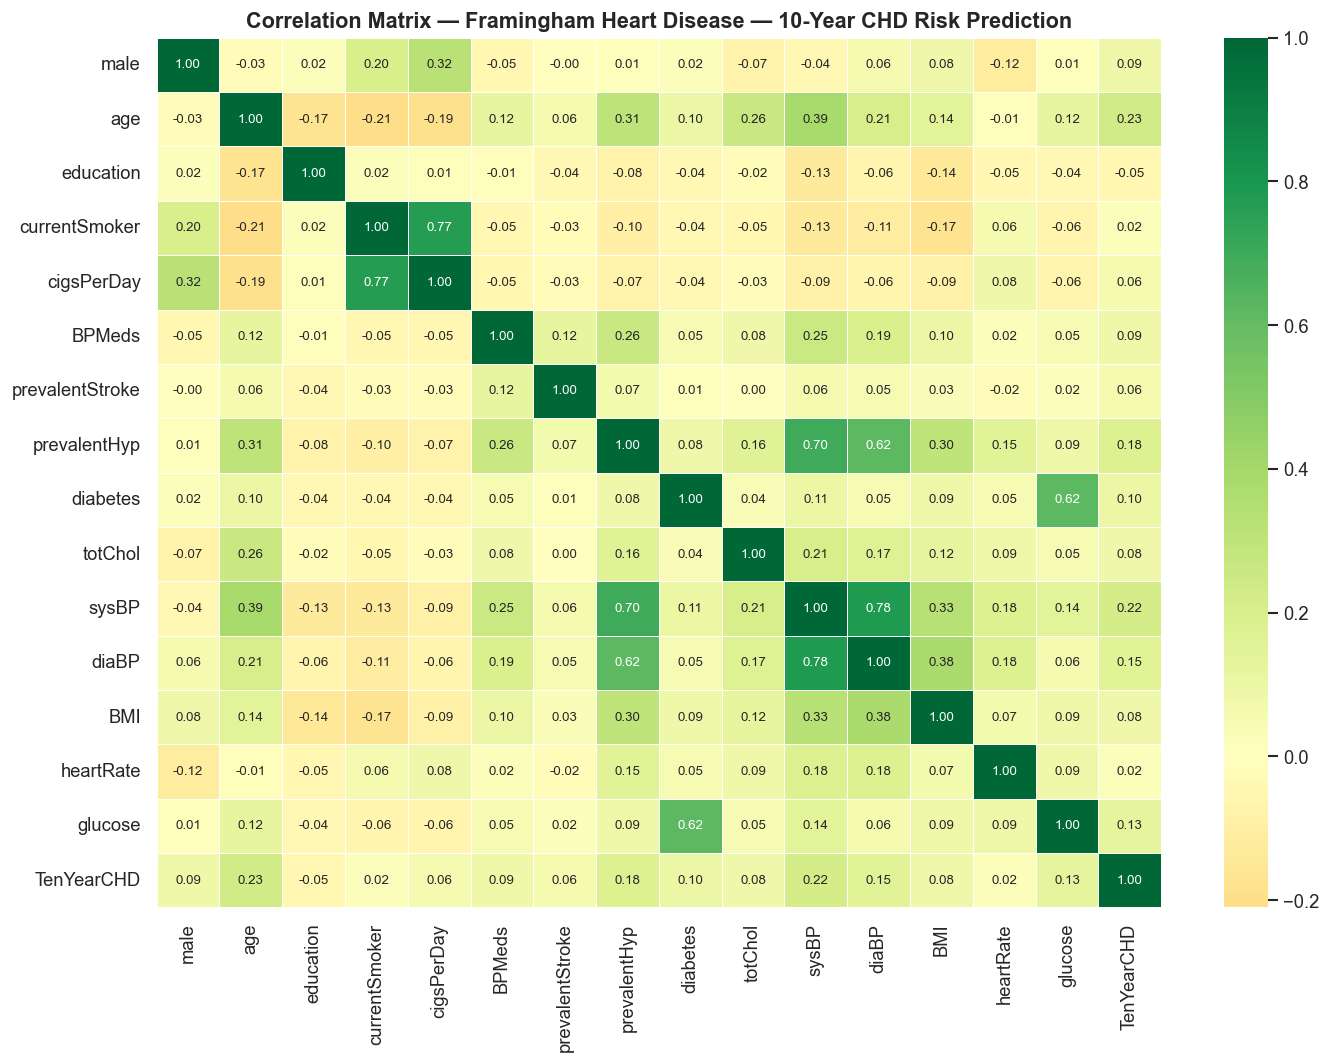

In [16]:
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include=[np.number]).corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size':8})
plt.title('Correlation Matrix — Framingham Heart Disease — 10-Year CHD Risk Prediction', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'TenYearCHD']

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col]    = df[col].fillna(median_val)
        print(f'  Filled {{col:<20}} with median = {{median_val:.4f}}')

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col]  = df[col].fillna(mode_val)
        print(f'  Filled {{col:<20}} with mode  = {{mode_val}}')

print(f'\nMissing values AFTER cleaning: {df.isnull().sum().sum()}')



Missing values AFTER cleaning: 0


In [22]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns found: {len(cat_cols)}')

if len(cat_cols) > 0:
    for col in cat_cols:
        print(f'  {col}: {df[col].unique()[:10]}')
    for col in cat_cols:
        if df[col].nunique() == 2:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            print(f'  Label Encoded: {col}')
        else:
            df = pd.get_dummies(df, columns=[col], drop_first=True)
            print(f'  One-Hot Encoded: {col}')
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)
    print(f'\n Encoding complete! New shape: {df.shape}')
else:
    print(' No categorical columns found — all features are already numeric!')

Categorical columns found: 0
 No categorical columns found — all features are already numeric!


In [23]:
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Class distribution before SMOTE:
TenYearCHD
0    2875
1     515
Imbalance ratio: 5.58:1

After SMOTE:
TenYearCHD
0    2875
1    2875
Dataset balanced with SMOTE!


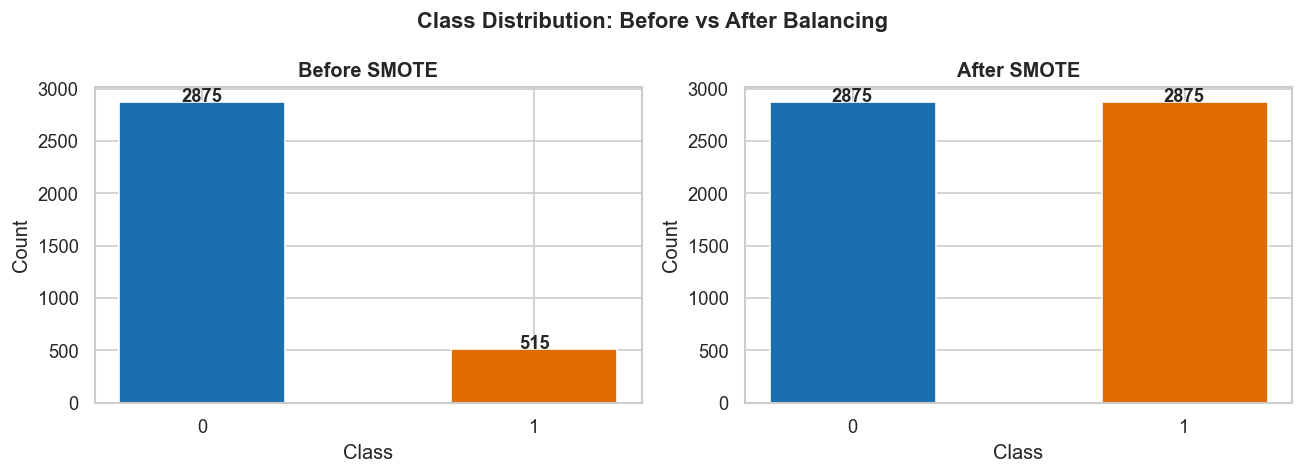

In [26]:
class_counts = y_train.value_counts()
imbalance    = class_counts.max() / class_counts.min()
print(f'Class distribution before SMOTE:\n{y_train.value_counts().to_string()}')
print(f'Imbalance ratio: {imbalance:.2f}:1')

if smote_available and imbalance > 1.3:
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
    print(f'\nAfter SMOTE:')
    print(pd.Series(y_train_bal).value_counts().to_string())
    print('Dataset balanced with SMOTE!')
else:
    X_train_bal, y_train_bal = X_train_scaled, y_train
    if not smote_available:
        print('SMOTE not available. Using class_weight="balanced" in models instead.')
    else:
        print('Dataset is balanced — SMOTE not needed.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Class Distribution: Before vs After Balancing', fontweight='bold')

before = y_train.value_counts()
axes[0].bar(before.index.astype(str), before.values,
            color=['#1a6faf','#e06c00'], edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

after = pd.Series(y_train_bal).value_counts()
axes[1].bar(after.index.astype(str), after.values,
            color=['#1a6faf','#e06c00'], edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'          : GaussianNB(),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                  : SVC(probability=True, random_state=42),
}

results  = []
y_preds  = {}

print(f'Training {len(models)} models...\n')

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test_scaled)
    y_preds[name] = y_pred

    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test,    y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test,        y_pred, average='weighted', zero_division=0)
    try:
        y_proba = model.predict_proba(X_test_scaled)[:,1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None

    results.append({'Model': name,
                    'Accuracy':  round(acc*100,  2),
                    'Precision': round(prec*100, 2),
                    'Recall':    round(rec*100,  2),
                    'F1-Score':  round(f1*100,   2),
                    'ROC-AUC':   round(auc*100,  2) if auc else None})
    print(f'   {name:<25} Acc={acc*100:.2f}%  F1={f1*100:.2f}%')


Training 7 models...

   Logistic Regression       Acc=66.39%  F1=70.90%
   K-Nearest Neighbors       Acc=64.27%  F1=69.00%
   Naive Bayes               Acc=77.36%  F1=77.06%
   Decision Tree             Acc=72.52%  F1=74.34%
   Random Forest             Acc=79.13%  F1=77.64%
   Gradient Boosting         Acc=76.65%  F1=77.56%
   SVM                       Acc=69.69%  F1=73.08%


In [29]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

print('='*80)
print('        MODEL PERFORMANCE COMPARISON (sorted by F1-Score)')
print('='*80)
print(results_df.to_string())
print('='*80)
print(f'\n Best Model: {results_df.iloc[0]["Model"]} (F1-Score = {results_df.iloc[0]["F1-Score"]}%)')

        MODEL PERFORMANCE COMPARISON (sorted by F1-Score)
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1        Random Forest     79.13      76.43   79.13     77.64    64.97
2    Gradient Boosting     76.65      78.62   76.65     77.56    65.34
3          Naive Bayes     77.36      76.77   77.36     77.06    68.24
4        Decision Tree     72.52      76.59   72.52     74.34    55.17
5                  SVM     69.69      78.58   69.69     73.08    65.04
6  Logistic Regression     66.39      80.37   66.39     70.90    69.69
7  K-Nearest Neighbors     64.27      77.92   64.27     69.00    59.94

 Best Model: Random Forest (F1-Score = 77.64%)


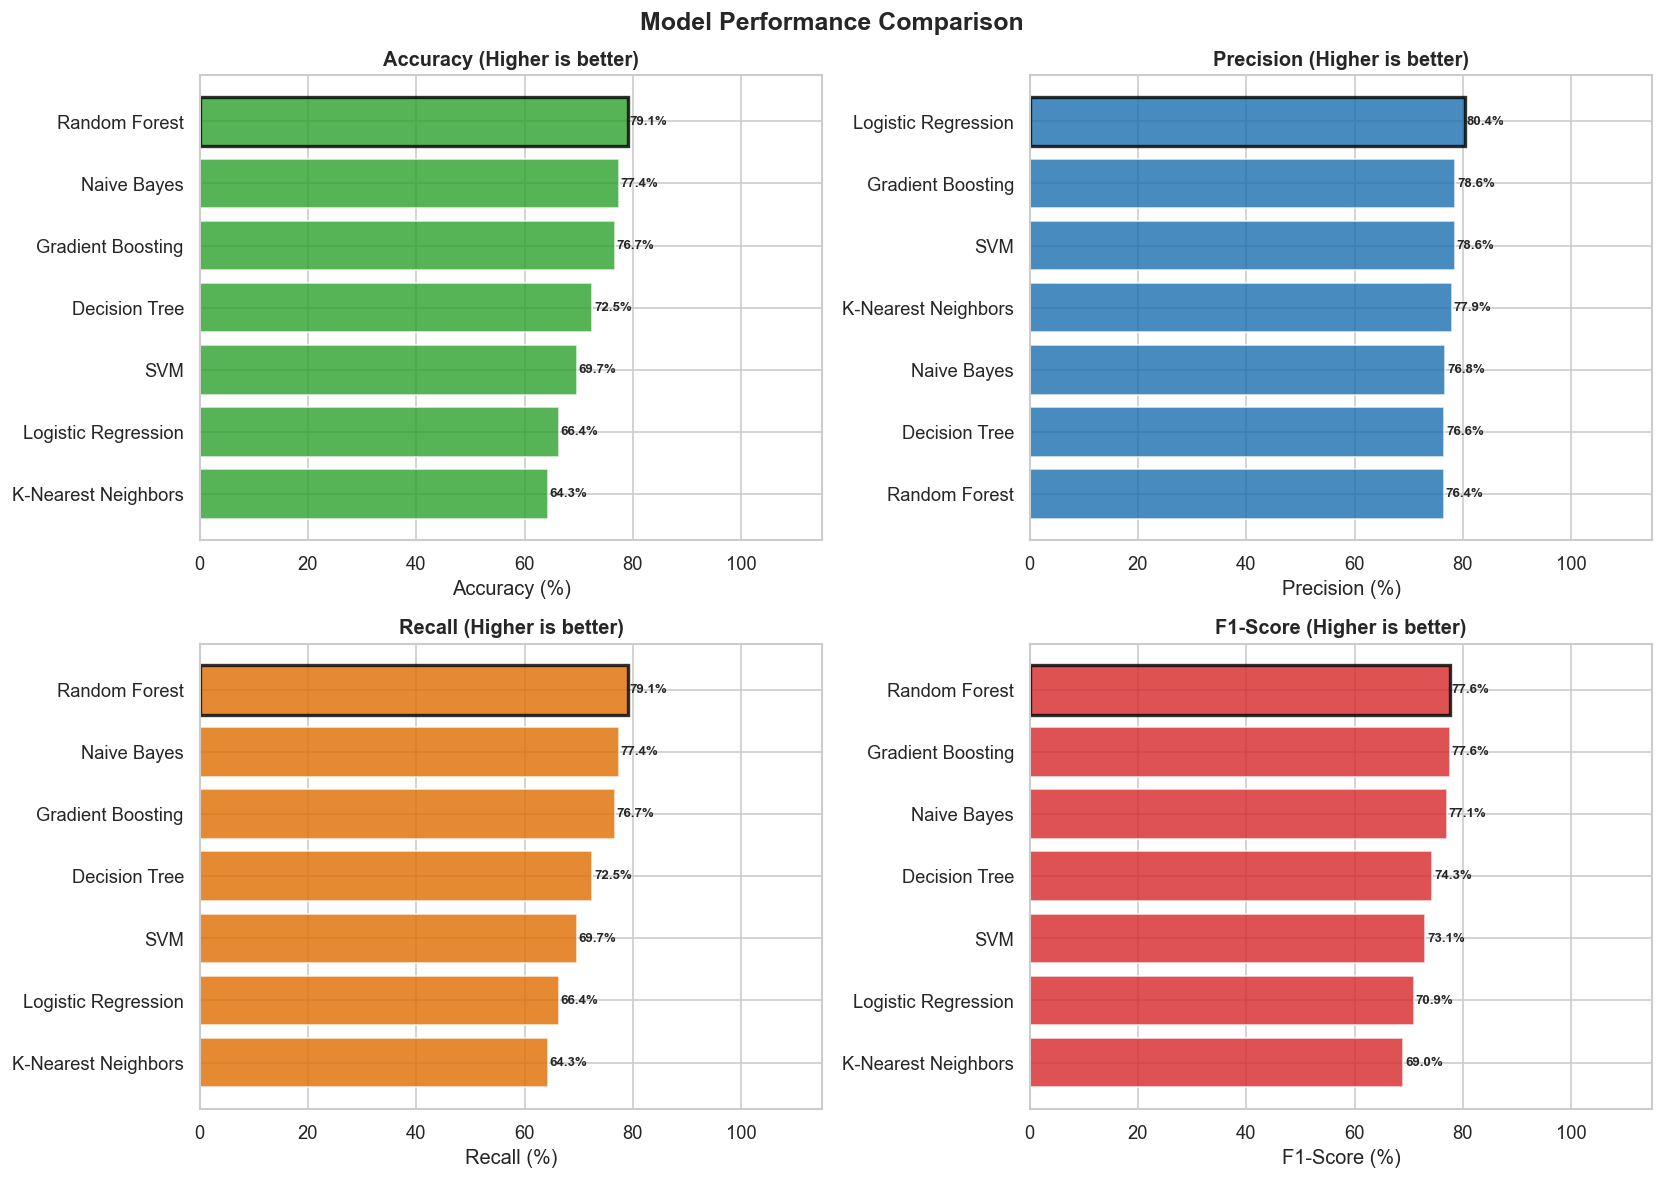

In [30]:
metrics = ['Accuracy','Precision','Recall','F1-Score']
colors  = ['#2ca02c','#1a6faf','#e06c00','#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, alpha=0.8, edgecolor='white')
    bars[-1].set_edgecolor('black'); bars[-1].set_linewidth(2)
    for bar in bars:
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=8, fontweight='bold')
    ax.set_title(f'{metric} (Higher is better)', fontweight='bold')
    ax.set_xlabel(f'{metric} (%)')
    ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()

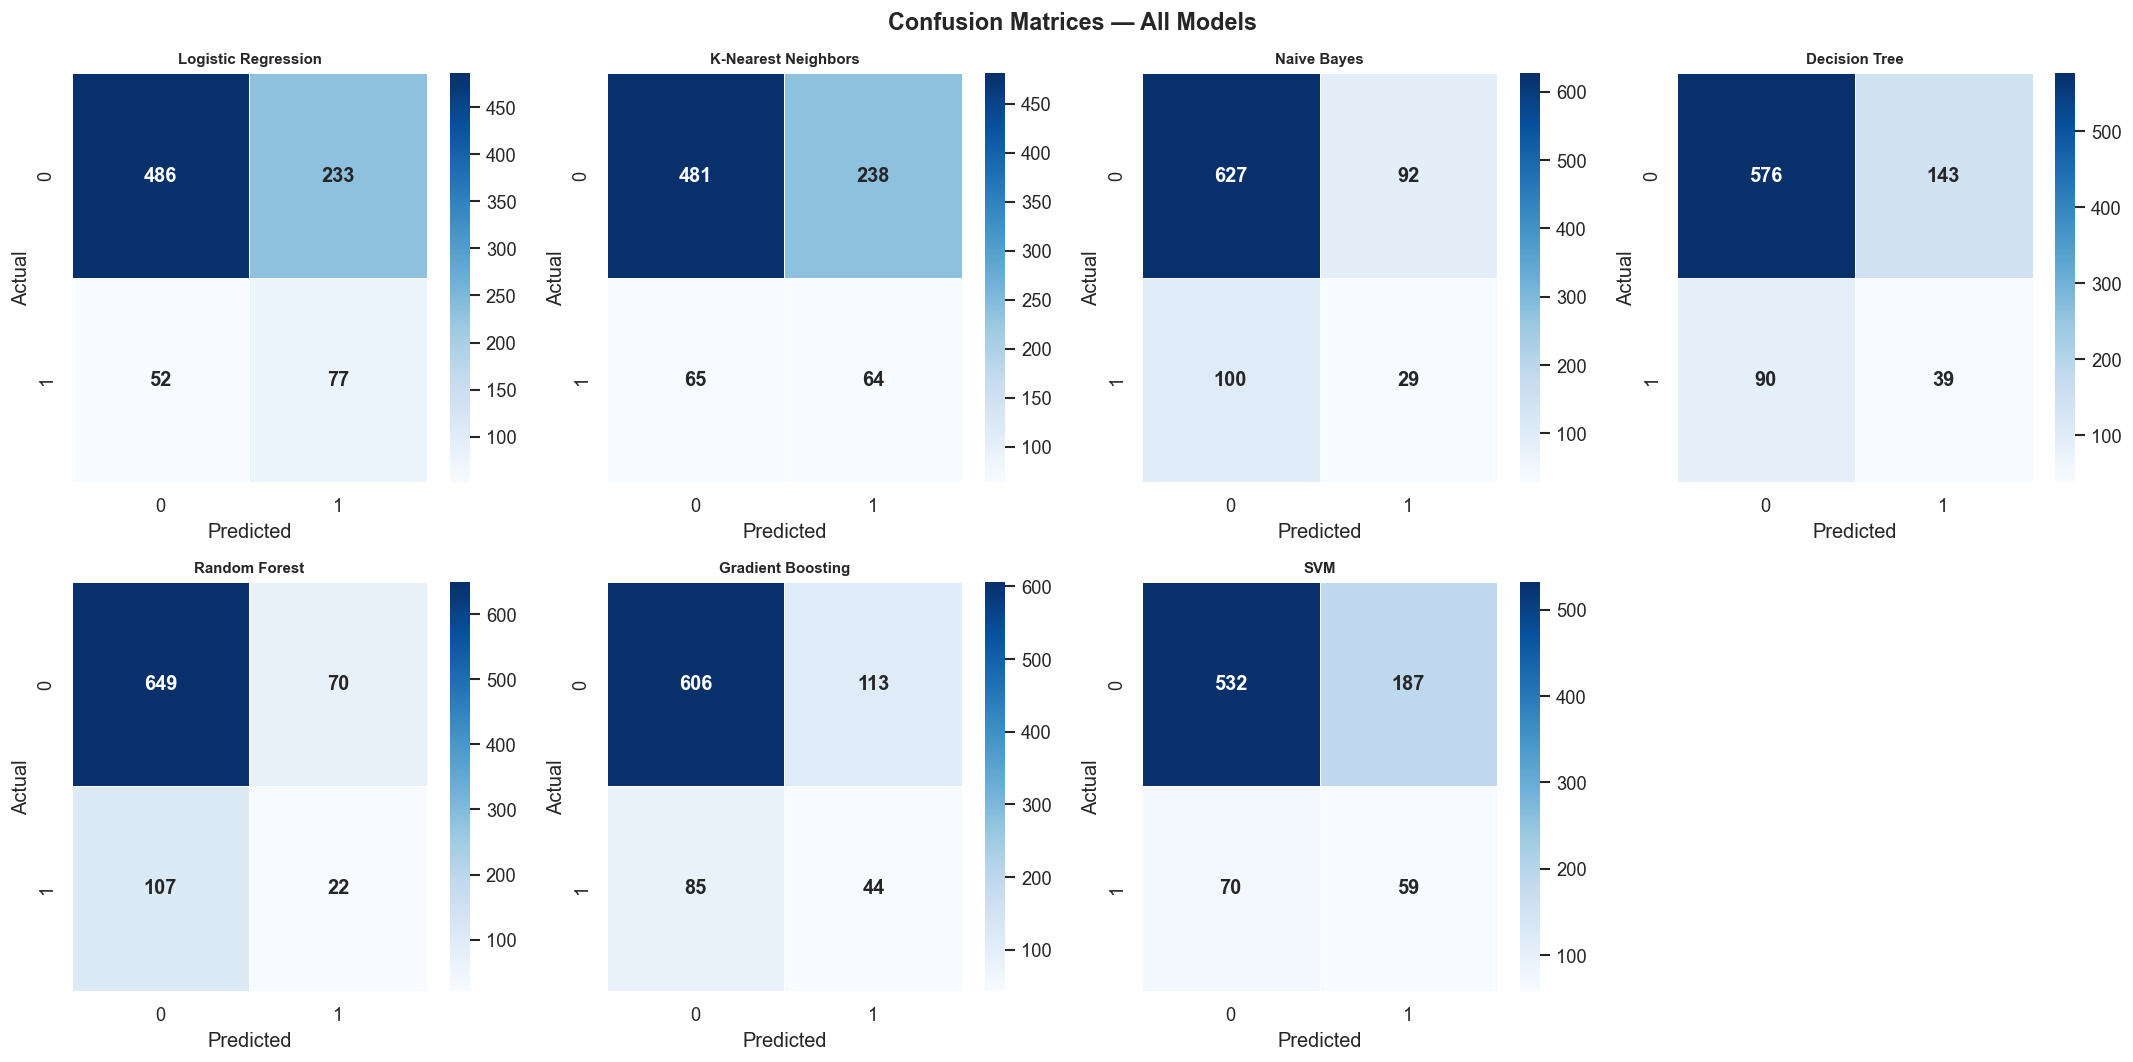

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, (name, y_pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes_flat[i],
                annot_kws={'size':12,'fontweight':'bold'})
    axes_flat[i].set_title(name, fontweight='bold', fontsize=9)
    axes_flat[i].set_xlabel('Predicted')
    axes_flat[i].set_ylabel('Actual')

axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

 Best Model: Random Forest

         CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       719
           1       0.24      0.17      0.20       129

    accuracy                           0.79       848
   macro avg       0.55      0.54      0.54       848
weighted avg       0.76      0.79      0.78       848



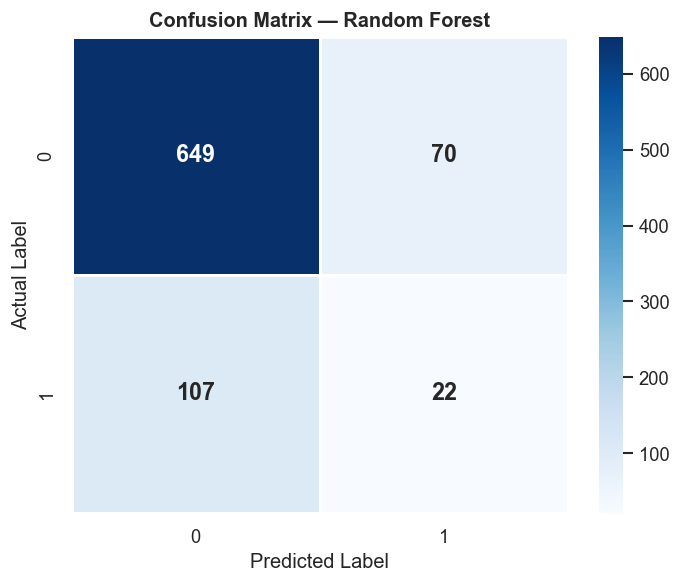

In [32]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj  = models[best_model_name]
y_pred_best     = y_preds[best_model_name]

print(f' Best Model: {best_model_name}')
print('\n' + '='*55)
print('         CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.8, annot_kws={'size':14,'fontweight':'bold'})
plt.title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

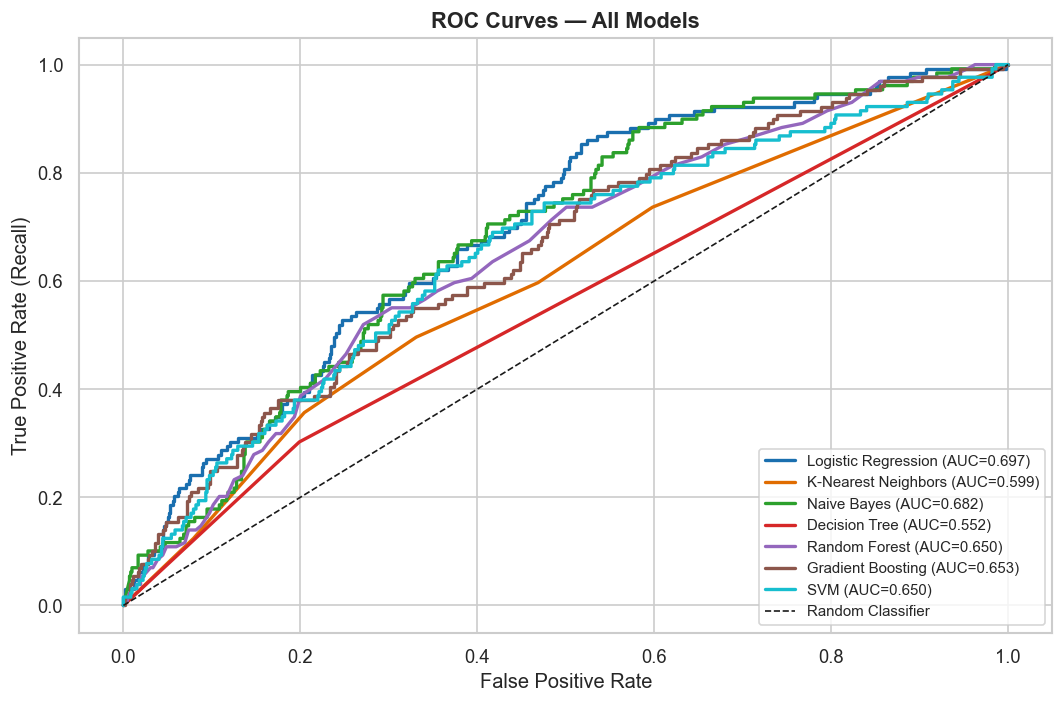

In [33]:
plt.figure(figsize=(9, 6))
colors_roc = ['#1a6faf','#e06c00','#2ca02c','#d62728','#9467bd','#8c564b','#17becf']

for (name, model), color in zip(models.items(), colors_roc):
    try:
        y_proba = model.predict_proba(X_test_scaled)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc:.3f})')
    except Exception:
        pass

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
top3_names = results_df.head(3)['Model'].tolist()
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Stratified 5-Fold Cross Validation Results:')
print(f'  {"Model":<28} {"Mean Acc":>10} {"Std Dev":>10} {"Min":>10} {"Max":>10}')
print('-'*72)

for name in top3_names:
    model  = models[name]
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=skf, scoring='accuracy')
    print(f'  {name:<28} {scores.mean()*100:>9.2f}% {scores.std()*100:>9.2f}%  {scores.min()*100:>9.2f}%  {scores.max()*100:>9.2f}%')


Stratified 5-Fold Cross Validation Results:
  Model                          Mean Acc    Std Dev        Min        Max
------------------------------------------------------------------------
  Random Forest                    90.85%      0.84%      89.83%      92.17%
  Gradient Boosting                83.48%      1.13%      81.39%      84.61%
  Naive Bayes                      59.79%      1.49%      58.00%      61.65%


Top 15 Most Important Features:
  age                                 0.1746  █████████████████
  sysBP                               0.1149  ███████████
  diaBP                               0.1013  ██████████
  heartRate                           0.0976  █████████
  totChol                             0.0945  █████████
  glucose                             0.0926  █████████
  education                           0.0901  █████████
  BMI                                 0.0896  ████████
  cigsPerDay                          0.0597  █████
  male                                0.0304  ███
  prevalentHyp                        0.0265  ██
  currentSmoker                       0.0153  █
  diabetes                            0.0060  
  BPMeds                              0.0049  
  prevalentStroke                     0.0019  


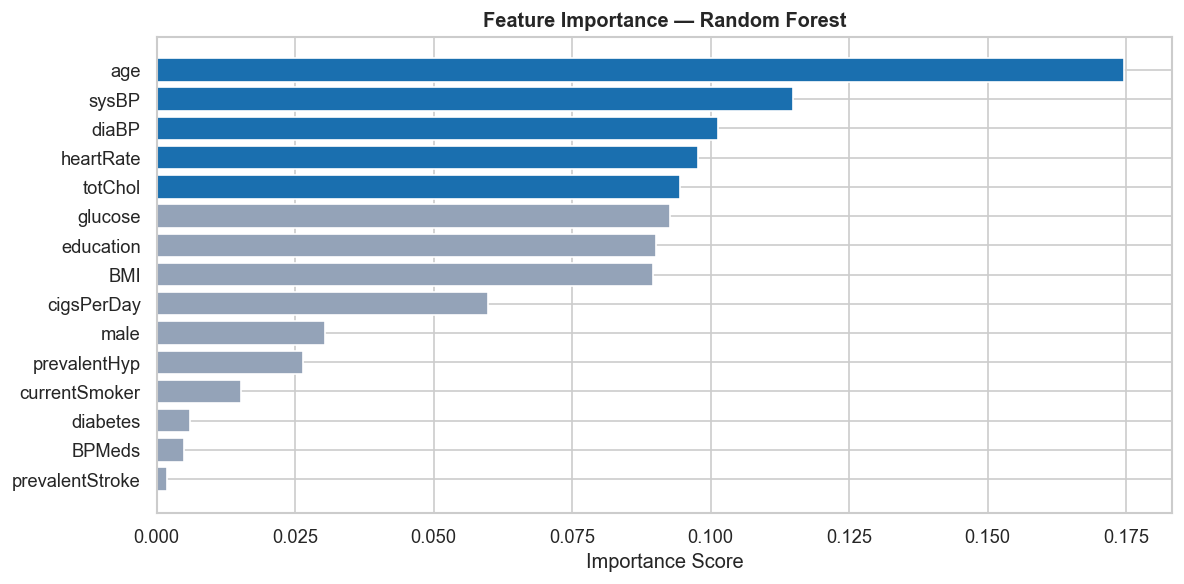

In [36]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_bal, y_train_bal)

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

print('Top 15 Most Important Features:')
for feat, imp in feat_imp.items():
    bar = '█' * int(imp * 100)
    print(f'  {feat:<35} {imp:.4f}  {bar}')

plt.figure(figsize=(10, 5))
colors = ['#1a6faf' if i < 5 else '#94a3b8' for i in range(len(feat_imp))]
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1],
         color=colors[::-1], edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [37]:
param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced']
}

total_fits = 3*3*2*2*3
print(f'GridSearchCV: {3*3*2*2} combinations × 3 folds = {total_fits} fits')
print('Training... (this may take a few minutes)\n')

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_bal, y_train_bal)

print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_*100:.2f}%')

GridSearchCV: 36 combinations × 3 folds = 108 fits
Training... (this may take a few minutes)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters : {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 Score: 89.69%


In [38]:
tuned_model  = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_scaled)

acc_t  = accuracy_score(y_test,  y_pred_tuned) * 100
prec_t = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0) * 100
rec_t  = recall_score(y_test,    y_pred_tuned, average='weighted', zero_division=0) * 100
f1_t   = f1_score(y_test,        y_pred_tuned, average='weighted', zero_division=0) * 100

acc_b  = results_df.iloc[0]['Accuracy']
f1_b   = results_df.iloc[0]['F1-Score']

print('='*58)
print('    TUNED MODEL vs BASE BEST MODEL COMPARISON')
print('='*58)
print(f'  {"Metric":<12} {"Base Best":>15} {"Tuned RF":>15}')
print('-'*58)
print(f'  {"Accuracy":<12} {acc_b:>14.2f}% {acc_t:>14.2f}%')
print(f'  {"F1-Score":<12} {f1_b:>14.2f}% {f1_t:>14.2f}%')
print(f'  {"Precision":<12} {" ":>15} {prec_t:>14.2f}%')
print(f'  {"Recall":<12} {" ":>15} {rec_t:>14.2f}%')
print('='*58)
print(f'\n WINNER: Tuned Random Forest')
print(f'   Accuracy : {acc_t:.2f}%')
print(f'   F1-Score : {f1_t:.2f}%')
print(f'   Precision: {prec_t:.2f}%')
print(f'   Recall   : {rec_t:.2f}%')

print('\nDetailed Classification Report (Tuned Model):')
print(classification_report(y_test, y_pred_tuned, zero_division=0))

    TUNED MODEL vs BASE BEST MODEL COMPARISON
  Metric             Base Best        Tuned RF
----------------------------------------------------------
  Accuracy              79.13%          80.19%
  F1-Score              77.64%          78.24%
  Precision                             76.79%
  Recall                                80.19%

 WINNER: Tuned Random Forest
   Accuracy : 80.19%
   F1-Score : 78.24%
   Precision: 76.79%
   Recall   : 80.19%

Detailed Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       719
           1       0.26      0.16      0.20       129

    accuracy                           0.80       848
   macro avg       0.56      0.54      0.54       848
weighted avg       0.77      0.80      0.78       848



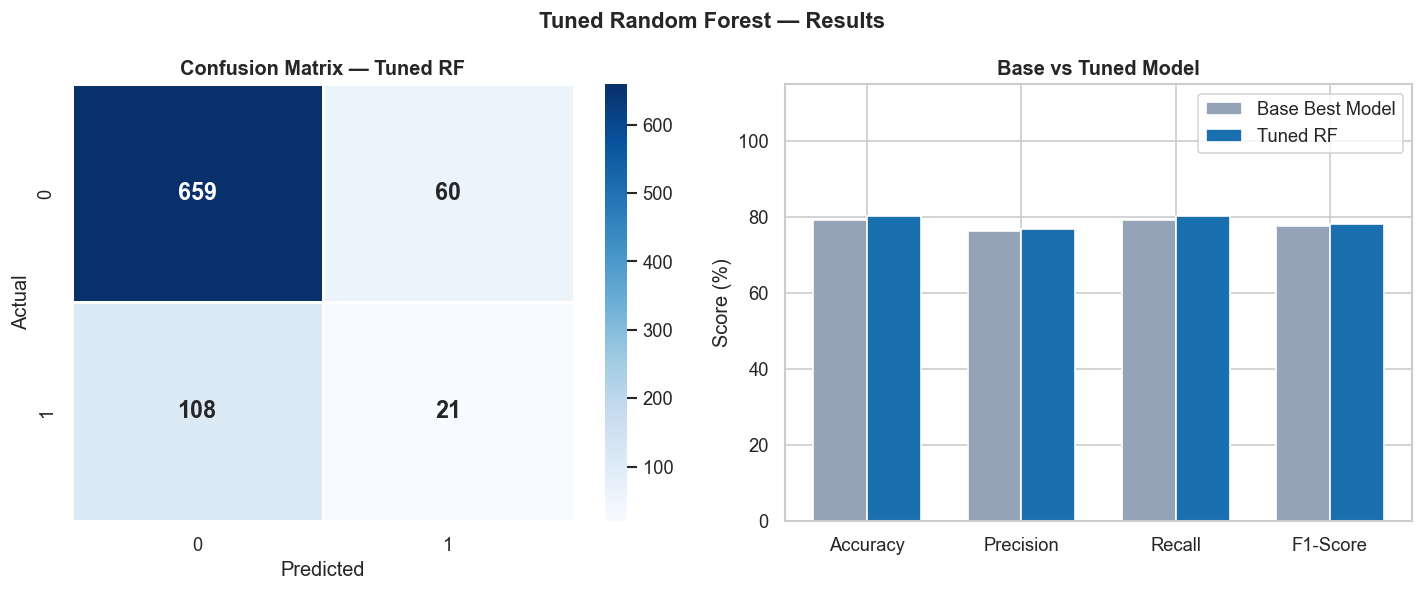

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Tuned Random Forest — Results', fontweight='bold')

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            linewidths=0.8, ax=axes[0], annot_kws={'size':14,'fontweight':'bold'})
axes[0].set_title('Confusion Matrix — Tuned RF', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

metric_names = ['Accuracy','Precision','Recall','F1-Score']
base_vals  = [acc_b, results_df.iloc[0]['Precision'], results_df.iloc[0]['Recall'], f1_b]
tuned_vals = [acc_t, prec_t, rec_t, f1_t]

x  = np.arange(len(metric_names))
w  = 0.35
axes[1].bar(x-w/2, base_vals,  width=w, label='Base Best Model', color='#94a3b8', edgecolor='white')
axes[1].bar(x+w/2, tuned_vals, width=w, label='Tuned RF',        color='#1a6faf', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].set_title('Base vs Tuned Model', fontweight='bold')
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Key Findings
- Age is the Strongest Single Predictor (r = 0.225)
- Males are at Significantly Higher Risk
- Systolic Blood Pressure is a Critical Warning Sign (r = 0.216)
- Hypertension Doubles the CHD Risk
- Diabetes is a Major Risk Multiplier
- Blood Pressure Medication Usage Signals Elevated Risk
- Smoking Has a Moderate Effect
- Cholesterol Levels are Elevated in CHD Patients
- Best Performing Model: Tuned Random Forest
- Glucose is an Underrated Predictor (r = 0.126)